# Diebold–Mariano Tests

This notebook implements Diebold–Mariano tests to compare the forecasting performance of the thesis models against the HAR-RV benchmark.

The comparison is based on QLIKE loss differences:

$$
d_t = L_{\text{model},t} - L_{\text{HAR},t}
$$

Negative values indicate that the alternative model performs better than HAR-RV.

The test uses Newey-West HAC variance estimation and the Harvey-Leybourne-Newbold small-sample correction.

Mounted at /content/drive
Models found per index:


,Symbol,Model,Rows
0,.FTSE,CR,2088
1,.FTSE,HAR,696
2,.FTSE,RFSV,1340
3,.FTSE,rBergomi,696
4,.HSI,CR,2028
5,.HSI,HAR,676
6,.HSI,RFSV,1345
7,.HSI,rBergomi,676
8,.IXIC,CR,2076
9,.IXIC,HAR,692


Alignment report:


,Index,Model,Aligned_with_HAR,Status
0,.FTSE,CR,696,ok
1,.FTSE,RFSV,696,ok
2,.FTSE,rBergomi,696,ok
3,.HSI,CR,676,ok
4,.HSI,RFSV,676,ok
5,.HSI,rBergomi,676,ok
6,.IXIC,CR,692,ok
7,.IXIC,RFSV,692,ok
8,.IXIC,rBergomi,692,ok
9,.N225,CR,672,ok


Diebold-Mariano test results:


,Index,Model vs HAR,Diff QLIKE,DM (HLN),p-value,L (NW),T (aligned),Sign.
0,.FTSE,CR,0.000384,3.087814,0.002097,11,696,**
1,.FTSE,RFSV,0.000372,0.175742,0.860548,11,696,
2,.FTSE,rBergomi,0.062074,1.254219,0.210184,11,696,
3,.HSI,CR,-0.000467,-3.121648,0.001875,11,676,**
4,.HSI,RFSV,-0.000583,-3.838049,0.000136,11,676,**
5,.HSI,rBergomi,-0.007643,-0.939365,0.347879,11,676,
6,.IXIC,CR,-0.000212,-0.377112,0.706206,11,692,
7,.IXIC,RFSV,0.000727,0.605561,0.545005,11,692,
8,.IXIC,rBergomi,0.091653,2.590402,0.009789,11,692,**
9,.N225,CR,-0.000011,-0.017328,0.986180,11,672,


Saved DM table to: /content/drive/MyDrive/thesis/results/metrics/dm_qlike_table.csv
Saved LaTeX table to: /content/drive/MyDrive/thesis/results/metrics/dm_qlike_table.tex


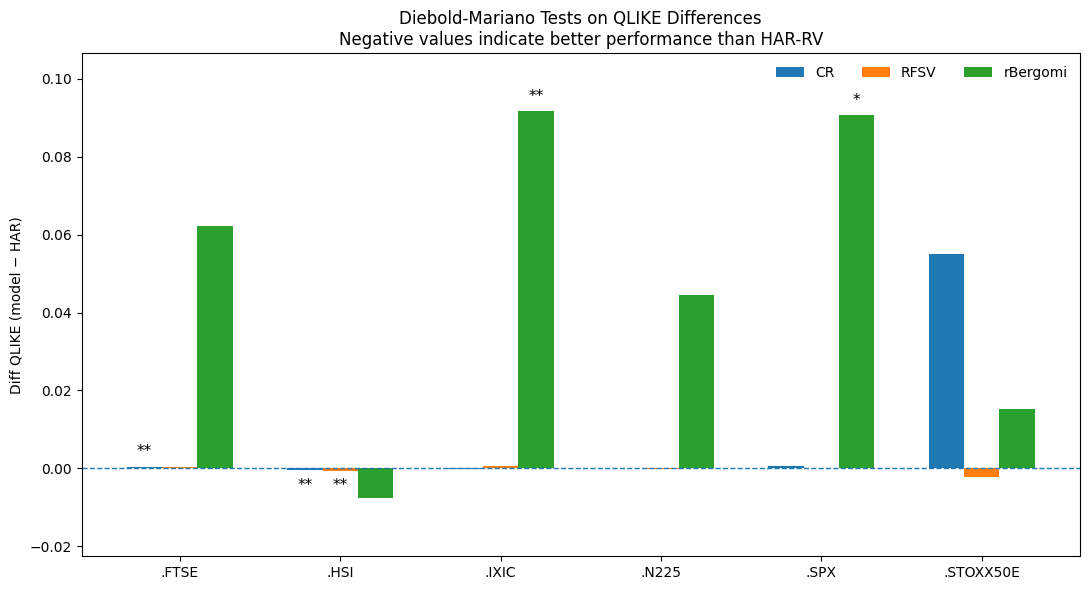

Saved DM figure to: /content/drive/MyDrive/thesis/results/figures/dm_qlike_bars.png
Diebold-Mariano analysis completed successfully.


In [1]:
# ============================================================
# DIEBOLD-MARIANO TESTS — QLIKE LOSS
# Master's Thesis: From Fractional to Rough Volatility
# Author: Elisa Battista
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t
from google.colab import drive

# ------------------------------------------------------------
# Google Drive Setup
# ------------------------------------------------------------

MOUNTPOINT = "/content/drive"

if not os.path.isdir(f"{MOUNTPOINT}/MyDrive"):
    drive.mount(MOUNTPOINT)

BASE = f"{MOUNTPOINT}/MyDrive/thesis"
PRED_DIR = f"{BASE}/results/preds"
RESULTS_DIR = f"{BASE}/results/metrics"
FIG_DIR = f"{BASE}/results/figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DM_CSV = f"{RESULTS_DIR}/dm_qlike_table.csv"
DM_LATEX = f"{RESULTS_DIR}/dm_qlike_table.tex"
ALIGNMENT_CSV = f"{RESULTS_DIR}/dm_alignment_report.csv"
DM_FIG = f"{FIG_DIR}/dm_qlike_bars.png"

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def normalize_symbol(symbol):
    symbol = str(symbol).strip()
    return symbol if symbol.startswith(".") else f".{symbol}"


def clean_model_label(raw_label):
    label = str(raw_label).strip()

    aliases = {
        "CRonly": "CR",
        "CR_only": "CR",
        "RFSVV": "RFSV",
        "RFS": "RFSV",
        "FSV": "RFSV",
        "rfs": "RFSV",
        "RB": "rBergomi",
        "rB": "rBergomi",
    }

    return aliases.get(label, label)


def qlike_from_logvol(y_true_log, y_pred_log):
    """
    Compute QLIKE losses from log-volatility forecasts.
    """
    y_true_log = np.asarray(y_true_log, dtype=np.float64)
    y_pred_log = np.asarray(y_pred_log, dtype=np.float64)

    var_true = np.exp(2.0 * y_true_log)
    var_pred = np.exp(2.0 * y_pred_log)

    ratio = var_true / var_pred

    return ratio - np.log(ratio) - 1.0


def newey_west_variance_of_mean(series, lag):
    """
    Newey-West HAC variance estimator for the sample mean.
    Bartlett weights are used.
    """
    series = np.asarray(series, dtype=np.float64)
    T = len(series)

    if T <= 1:
        raise ValueError("Series too short for HAC variance.")

    centered = series - series.mean()

    gamma_0 = np.dot(centered, centered) / T
    variance = gamma_0

    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1.0)
        gamma_k = np.dot(centered[k:], centered[:-k]) / T
        variance += 2.0 * weight * gamma_k

    return variance / T


def diebold_mariano_test(loss_model, loss_benchmark, lag=None, horizon=1):
    """
    Two-sided Diebold-Mariano test for equal predictive accuracy.

    H0: E[L_model - L_benchmark] = 0

    Returns:
    DM-HLN statistic, p-value, mean loss differential,
    Newey-West lag, and aligned sample size.
    """
    differential = (
        np.asarray(loss_model, dtype=np.float64)
        - np.asarray(loss_benchmark, dtype=np.float64)
    )

    differential = differential[np.isfinite(differential)]

    T = len(differential)

    if T < 10:
        raise ValueError(f"Too few observations for DM test: T={T}")

    if lag is None:
        lag = max(horizon, int(np.floor(1.3 * T ** (1 / 3))))

    var_mean = newey_west_variance_of_mean(differential, lag)

    if var_mean <= 0 or not np.isfinite(var_mean):
        raise ValueError("Invalid HAC variance.")

    dm_stat = differential.mean() / np.sqrt(var_mean)

    correction = np.sqrt(
        (T + 1 - 2 * horizon + (horizon * (horizon - 1)) / T) / T
    )

    dm_hln = dm_stat * correction

    p_value = 2.0 * (1.0 - t.cdf(abs(dm_hln), df=T - 1))

    return dm_hln, p_value, differential.mean(), lag, T


def significance_stars(p_value):
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    if p_value < 0.10:
        return "•"
    return ""


# ------------------------------------------------------------
# Load Prediction Files
# ------------------------------------------------------------

prediction_paths = sorted(
    glob.glob(os.path.join(PRED_DIR, "pred_test_*.csv"))
)

if not prediction_paths:
    raise FileNotFoundError(
        f"No prediction files found in {PRED_DIR}."
    )

long_rows = []

for path in prediction_paths:
    pred_df = pd.read_csv(path)

    required_columns = {"Symbol", "Date_target", "y_true"}

    if not required_columns.issubset(pred_df.columns):
        continue

    symbol = normalize_symbol(pred_df["Symbol"].dropna().iloc[0])

    dates = pd.to_datetime(pred_df["Date_target"], errors="coerce")
    valid_dates = dates.notna().values

    prediction_columns = [
        col for col in pred_df.columns
        if col.startswith("y_pred_")
    ]

    for col in prediction_columns:
        raw_model = col.replace("y_pred_", "")
        model = clean_model_label(raw_model)

        if model not in {"HAR", "CR", "RFSV", "rBergomi"}:
            continue

        temp = pd.DataFrame({
            "Symbol": symbol,
            "Date_target": dates[valid_dates].values,
            "Model": model,
            "y_true_log": pred_df.loc[valid_dates, "y_true"].to_numpy(),
            "y_pred_log": pred_df.loc[valid_dates, col].to_numpy(),
        })

        long_rows.append(temp)

if not long_rows:
    raise RuntimeError(
        "No usable prediction columns found. Expected columns such as "
        "y_pred_HAR, y_pred_CR, y_pred_RFSV, y_pred_rBergomi."
    )

long_df = pd.concat(long_rows, ignore_index=True)

print("Models found per index:")
display(
    long_df.groupby(["Symbol", "Model"])
    .size()
    .reset_index(name="Rows")
    .sort_values(["Symbol", "Model"])
)

# ------------------------------------------------------------
# Align Forecasts and Run DM Tests
# ------------------------------------------------------------

agg_df = (
    long_df
    .groupby(["Symbol", "Date_target", "Model"], as_index=False)
    .agg(
        y_true_log=("y_true_log", "first"),
        y_pred_log=("y_pred_log", "first")
    )
)

dm_results = []
alignment_rows = []

for symbol in sorted(agg_df["Symbol"].unique()):

    sub = agg_df[agg_df["Symbol"] == symbol].copy()

    har = (
        sub[sub["Model"] == "HAR"]
        [["Date_target", "y_true_log", "y_pred_log"]]
        .set_index("Date_target")
        .sort_index()
    )

    if har.empty:
        print(f"Warning: no HAR predictions found for {symbol}.")
        continue

    for model in ["CR", "RFSV", "rBergomi"]:

        model_df = (
            sub[sub["Model"] == model]
            [["Date_target", "y_true_log", "y_pred_log"]]
            .set_index("Date_target")
            .sort_index()
        )

        if model_df.empty:
            alignment_rows.append({
                "Index": symbol,
                "Model": model,
                "Aligned_with_HAR": 0,
                "Status": "missing"
            })
            continue

        common_dates = har.index.intersection(model_df.index)
        n_aligned = len(common_dates)

        if n_aligned < 10:
            alignment_rows.append({
                "Index": symbol,
                "Model": model,
                "Aligned_with_HAR": n_aligned,
                "Status": "too_few"
            })
            continue

        alignment_rows.append({
            "Index": symbol,
            "Model": model,
            "Aligned_with_HAR": n_aligned,
            "Status": "ok"
        })

        y_true = har.loc[common_dates, "y_true_log"].to_numpy()

        loss_har = qlike_from_logvol(
            y_true,
            har.loc[common_dates, "y_pred_log"].to_numpy()
        )

        loss_model = qlike_from_logvol(
            y_true,
            model_df.loc[common_dates, "y_pred_log"].to_numpy()
        )

        dm_stat, p_value, diff, lag_used, T_used = diebold_mariano_test(
            loss_model,
            loss_har,
            lag=None,
            horizon=1
        )

        dm_results.append({
            "Index": symbol,
            "Model vs HAR": model,
            "Diff QLIKE": diff,
            "DM (HLN)": dm_stat,
            "p-value": p_value,
            "L (NW)": lag_used,
            "T (aligned)": T_used,
            "Sign.": significance_stars(p_value),
        })

alignment_df = (
    pd.DataFrame(alignment_rows)
    .sort_values(["Index", "Model"])
    .reset_index(drop=True)
)

alignment_df.to_csv(ALIGNMENT_CSV, index=False)

print("Alignment report:")
display(alignment_df)

if not dm_results:
    raise RuntimeError(
        "No DM test results produced. Check that CR, RFSV and rBergomi "
        "predictions exist alongside HAR predictions."
    )

dm_df = (
    pd.DataFrame(dm_results)
    .sort_values(["Index", "Model vs HAR"])
    .reset_index(drop=True)
)

dm_df.to_csv(DM_CSV, index=False)

latex_table = dm_df.to_latex(
    index=False,
    caption=(
        "Diebold-Mariano tests on QLIKE differences "
        "(model minus HAR), with Newey-West HAC variance and "
        "Harvey-Leybourne-Newbold small-sample correction."
    ),
    label="tab:dm_qlike",
    float_format="%.4f"
)

with open(DM_LATEX, "w", encoding="utf-8") as file:
    file.write(latex_table)

print("Diebold-Mariano test results:")
display(dm_df)

print(f"Saved DM table to: {DM_CSV}")
print(f"Saved LaTeX table to: {DM_LATEX}")

# ------------------------------------------------------------
# Plot DM QLIKE Differences
# ------------------------------------------------------------

model_order = ["CR", "RFSV", "rBergomi"]
indices = sorted(dm_df["Index"].unique())

diff_matrix = np.full(
    (len(indices), len(model_order)),
    np.nan
)

stars_matrix = np.empty(
    (len(indices), len(model_order)),
    dtype=object
)

stars_matrix[:] = ""

for i, index in enumerate(indices):
    sub = dm_df[dm_df["Index"] == index]

    for j, model in enumerate(model_order):
        row = sub[sub["Model vs HAR"] == model]

        if len(row) == 1:
            diff_matrix[i, j] = float(row["Diff QLIKE"].iloc[0])
            stars_matrix[i, j] = row["Sign."].iloc[0]

valid_values = diff_matrix[np.isfinite(diff_matrix)]

if valid_values.size == 0:
    raise RuntimeError("No valid Diff QLIKE values available for plotting.")

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(indices))
width = 0.22
offsets = np.linspace(-width, width, len(model_order))

y_min = float(np.min(valid_values))
y_max = float(np.max(valid_values))
y_range = y_max - y_min if y_max > y_min else 0.02
padding = 0.15 * y_range

ax.set_ylim(y_min - padding, y_max + padding)

for j, model in enumerate(model_order):
    values = diff_matrix[:, j]

    bars = ax.bar(
        x + offsets[j],
        values,
        width,
        label=model
    )

    for k, bar in enumerate(bars):
        value = values[k]

        if not np.isfinite(value):
            continue

        star = stars_matrix[k, j]

        if star == "":
            continue

        vertical_offset = 0.03 * (
            ax.get_ylim()[1] - ax.get_ylim()[0]
        )

        y_text = (
            bar.get_height() + vertical_offset
            if value >= 0
            else bar.get_height() - vertical_offset
        )

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_text,
            star,
            ha="center",
            va="center",
            fontsize=11
        )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(indices)

ax.set_ylabel("Diff QLIKE (model − HAR)")
ax.set_title(
    "Diebold-Mariano Tests on QLIKE Differences\n"
    "Negative values indicate better performance than HAR-RV"
)

ax.legend(ncol=3, frameon=False)

fig.tight_layout()
fig.savefig(DM_FIG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved DM figure to: {DM_FIG}")
print("Diebold-Mariano analysis completed successfully.")